In [11]:
import sys
mods_to_remove = [key for key in sys.modules if 'src' in key]
for mod in mods_to_remove:
    del sys.modules[mod]

from src.inference.gradcam import GradCAM
from src.models.densenet import DenseNetModel
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT_PATH = "D:/cxr-triage/checkpoints/clahe_320_logits_fix/best_model.pth"

model = DenseNetModel(num_classes=14, pretrained=False).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

gradcam = GradCAM(model)
print("GradCAM initialized successfully")

GradCAM initialized successfully


c:\Users\shamr\anaconda3\envs\cxr\lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


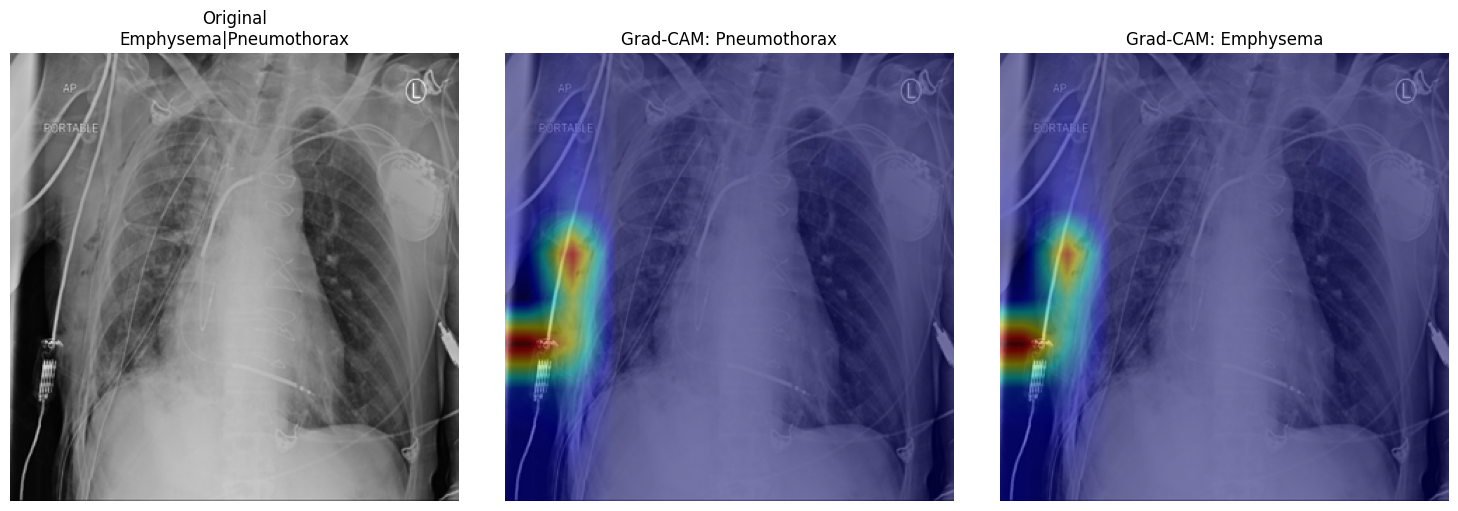

Done


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import pandas as pd
import os
from src.data.transforms import get_val_transforms

LABELS = [
    'Atelectasis', 'Consolidation', 'Infiltration',
    'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis',
    'Effusion', 'Pneumonia', 'Pleural_Thickening',
    'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

IMAGE_ROOT = "F:/X ray dataset/Second Version"
test_df = pd.read_csv('D:/cxr-triage/data/processed/test.csv')

# Find a Pneumothorax case
pneumothorax_cases = test_df[test_df['Finding Labels'].str.contains('Pneumothorax')]
sample_row = pneumothorax_cases.iloc[0]

# Find image path
image_path = None
for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
    path = os.path.join(IMAGE_ROOT, folder, "images", sample_row['Image Index'])
    if os.path.exists(path):
        image_path = path
        break

# Load original image
original_img = PILImage.open(image_path).convert('RGB')
original_np = np.array(original_img.resize((320, 320)))

# Prepare tensor
transform = get_val_transforms(image_size=320, use_clahe=True)
img_tensor = transform(PILImage.open(image_path).convert('RGB')).unsqueeze(0)

# Generate heatmaps
pneumothorax_idx = LABELS.index('Pneumothorax')
emphysema_idx = LABELS.index('Emphysema')

heatmap_pneumothorax = gradcam.generate(img_tensor.clone(), pneumothorax_idx)
overlay_pneumothorax, _ = gradcam.overlay(heatmap_pneumothorax, original_np)

heatmap_emphysema = gradcam.generate(img_tensor.clone(), emphysema_idx)
overlay_emphysema, _ = gradcam.overlay(heatmap_emphysema, original_np)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_np, cmap='gray')
axes[0].set_title(f'Original\n{sample_row["Finding Labels"]}')
axes[0].axis('off')
axes[1].imshow(overlay_pneumothorax)
axes[1].set_title('Grad-CAM: Pneumothorax')
axes[1].axis('off')
axes[2].imshow(overlay_emphysema)
axes[2].set_title('Grad-CAM: Emphysema')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('D:/cxr-triage/notebooks/gradcam_sample.png', dpi=150)
plt.show()
print("Done")

In [13]:
# Find Pneumothorax cases, filter out ones likely to have tubes
# Proxy: avoid images also labeled with many other findings
# (complex cases are more likely to have hardware)
pneumo_only = test_df[
    test_df['Finding Labels'] == 'Pneumothorax'
]
print(f"Pure Pneumothorax cases: {len(pneumo_only)}")
print(pneumo_only[['Image Index', 'Finding Labels']].head(10))

Pure Pneumothorax cases: 953
          Image Index Finding Labels
19   00000013_011.png   Pneumothorax
20   00000013_012.png   Pneumothorax
21   00000013_013.png   Pneumothorax
28   00000013_020.png   Pneumothorax
41   00000013_033.png   Pneumothorax
44   00000013_036.png   Pneumothorax
47   00000013_039.png   Pneumothorax
140  00000116_012.png   Pneumothorax
297  00000211_023.png   Pneumothorax
335  00000246_008.png   Pneumothorax


Image: 00000013_036.png
Finding: Pneumothorax


c:\Users\shamr\anaconda3\envs\cxr\lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


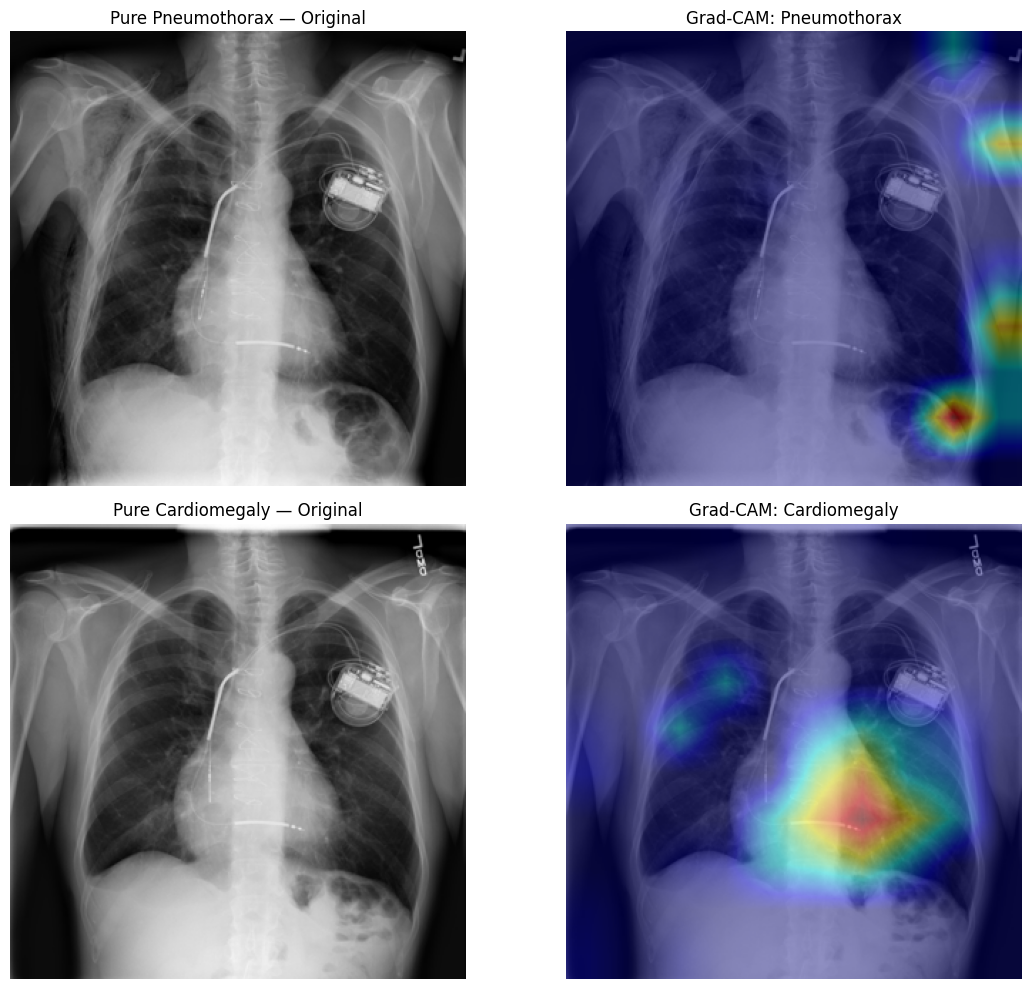

In [14]:
# Use a pure Pneumothorax case — no tubes/hardware confound
sample_row = pneumo_only.iloc[5]  # try a few different ones
print(f"Image: {sample_row['Image Index']}")
print(f"Finding: {sample_row['Finding Labels']}")

# Find image path
image_path = None
for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
    path = os.path.join(IMAGE_ROOT, folder, "images", sample_row['Image Index'])
    if os.path.exists(path):
        image_path = path
        break

# Load and prepare
original_img = PILImage.open(image_path).convert('RGB')
original_np = np.array(original_img.resize((320, 320)))
img_tensor = transform(PILImage.open(image_path).convert('RGB')).unsqueeze(0)

# Generate heatmap
pneumothorax_idx = LABELS.index('Pneumothorax')
heatmap = gradcam.generate(img_tensor.clone(), pneumothorax_idx)
overlay, _ = gradcam.overlay(heatmap, original_np)

# Also do Cardiomegaly on a clean case
cardio_cases = test_df[test_df['Finding Labels'] == 'Cardiomegaly']
sample_cardio = cardio_cases.iloc[0]
cardio_path = None
for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
    path = os.path.join(IMAGE_ROOT, folder, "images", sample_cardio['Image Index'])
    if os.path.exists(path):
        cardio_path = path
        break

original_cardio = np.array(PILImage.open(cardio_path).convert('RGB').resize((320, 320)))
img_tensor_cardio = transform(PILImage.open(cardio_path).convert('RGB')).unsqueeze(0)
cardio_idx = LABELS.index('Cardiomegaly')
heatmap_cardio = gradcam.generate(img_tensor_cardio.clone(), cardio_idx)
overlay_cardio, _ = gradcam.overlay(heatmap_cardio, original_cardio)

# Plot both
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].imshow(original_np, cmap='gray')
axes[0,0].set_title('Pure Pneumothorax — Original')
axes[0,0].axis('off')

axes[0,1].imshow(overlay)
axes[0,1].set_title('Grad-CAM: Pneumothorax')
axes[0,1].axis('off')

axes[1,0].imshow(original_cardio, cmap='gray')
axes[1,0].set_title('Pure Cardiomegaly — Original')
axes[1,0].axis('off')

axes[1,1].imshow(overlay_cardio)
axes[1,1].set_title('Grad-CAM: Cardiomegaly')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('D:/cxr-triage/notebooks/gradcam_clean_cases.png', dpi=150)
plt.show()

In [15]:
print(f"Image: {sample_row['Image Index']}")
print(f"Finding: {sample_row['Finding Labels']}")

Image: 00000013_036.png
Finding: Pneumothorax


In [16]:
bbox_df = pd.read_csv('F:/X ray dataset/Second Version/BBox_List_2017.csv')
print(bbox_df.shape)
print(bbox_df.columns.tolist())
print(bbox_df.head())

(984, 9)
['Image Index', 'Finding Label', 'Bbox [x', 'y', 'w', 'h]', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']
        Image Index Finding Label     Bbox [x           y           w  \
0  00013118_008.png   Atelectasis  225.084746  547.019217   86.779661   
1  00014716_007.png   Atelectasis  686.101695  131.543498  185.491525   
2  00029817_009.png   Atelectasis  221.830508  317.053115  155.118644   
3  00014687_001.png   Atelectasis  726.237288  494.951420  141.016949   
4  00017877_001.png   Atelectasis  660.067797  569.780787  200.677966   

           h]  Unnamed: 6  Unnamed: 7  Unnamed: 8  
0   79.186441         NaN         NaN         NaN  
1  313.491525         NaN         NaN         NaN  
2  216.949153         NaN         NaN         NaN  
3   55.322034         NaN         NaN         NaN  
4   78.101695         NaN         NaN         NaN  


In [17]:
# Clean up the bbox dataframe
bbox_df = bbox_df.rename(columns={
    'Bbox [x': 'x',
    'y': 'y', 
    'w': 'w',
    'h]': 'h'
})[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]

print(bbox_df.shape)
print(bbox_df['Finding Label'].value_counts())
print(bbox_df.head())

(984, 6)
Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64
        Image Index Finding Label           x           y           w  \
0  00013118_008.png   Atelectasis  225.084746  547.019217   86.779661   
1  00014716_007.png   Atelectasis  686.101695  131.543498  185.491525   
2  00029817_009.png   Atelectasis  221.830508  317.053115  155.118644   
3  00014687_001.png   Atelectasis  726.237288  494.951420  141.016949   
4  00017877_001.png   Atelectasis  660.067797  569.780787  200.677966   

            h  
0   79.186441  
1  313.491525  
2  216.949153  
3   55.322034  
4   78.101695  


In [ ]:
import cv2
import numpy as np

def compute_iou(heatmap, bbox, original_size=1024, target_size=320, threshold=0.2):
    x, y, w, h = bbox
    
    # Resize heatmap to target size first
    heatmap_resized = cv2.resize(
        heatmap.astype(np.float32), 
        (target_size, target_size)
    )
    
    # Scale bbox from original 1024x1024 to target size
    scale = target_size / original_size
    x_s = int(x * scale)
    y_s = int(y * scale)
    w_s = max(1, int(w * scale))
    h_s = max(1, int(h * scale))
    
    # Create ground truth mask
    gt_mask = np.zeros((target_size, target_size), dtype=np.uint8)
    gt_mask[y_s:y_s+h_s, x_s:x_s+w_s] = 1
    
    # Create predicted mask by thresholding heatmap
    pred_mask = (heatmap_resized >= threshold).astype(np.uint8)
    
    # Compute IoU
    intersection = (gt_mask & pred_mask).sum()
    union = (gt_mask | pred_mask).sum()
    
    if union == 0:
        return 0.0
    
    return float(intersection) / float(union)

print("compute_iou redefined — version 3")

compute_iou redefined — version 2


In [26]:
from tqdm import tqdm

# Label name mapping between bbox file and our LABELS list
label_map = {
    'Atelectasis': 'Atelectasis',
    'Effusion': 'Effusion',
    'Cardiomegaly': 'Cardiomegaly',
    'Infiltrate': 'Infiltration',
    'Pneumonia': 'Pneumonia',
    'Pneumothorax': 'Pneumothorax',
    'Mass': 'Mass',
    'Nodule': 'Nodule'
}

results = {label: [] for label in label_map.keys()}

for idx, row in tqdm(bbox_df.iterrows(), total=len(bbox_df), desc="IoU validation"):
    finding = row['Finding Label']
    if finding not in label_map:
        continue
    
    our_label = label_map[finding]
    class_idx = LABELS.index(our_label)
    
    # Find image path
    image_path = None
    for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
        path = os.path.join(IMAGE_ROOT, folder, "images", row['Image Index'])
        if os.path.exists(path):
            image_path = path
            break
    
    if image_path is None:
        continue
    
    # Load and prepare image
    try:
        img = PILImage.open(image_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0)
        
        # Generate heatmap
        heatmap = gradcam.generate(img_tensor.clone(), class_idx)
        
        # Compute IoU
        bbox = (row['x'], row['y'], row['w'], row['h'])
        iou = compute_iou(heatmap, bbox)
        results[finding].append(iou)
    except Exception as e:
        continue

# Print results
print(f"\n{'Finding':<20} {'Count':<8} {'Mean IoU':<12} {'IoU>0.1':<12} {'IoU>0.25':<12}")
print("-" * 65)

all_ious = []
for finding, ious in results.items():
    if len(ious) == 0:
        continue
    ious_arr = np.array(ious)
    all_ious.extend(ious)
    mean_iou = ious_arr.mean()
    acc_01 = (ious_arr > 0.1).mean()
    acc_025 = (ious_arr > 0.25).mean()
    print(f"{finding:<20} {len(ious):<8} {mean_iou:<12.4f} {acc_01:<12.4f} {acc_025:<12.4f}")

print("-" * 65)
all_ious = np.array(all_ious)
print(f"{'Overall':<20} {len(all_ious):<8} {all_ious.mean():<12.4f} {(all_ious>0.1).mean():<12.4f} {(all_ious>0.25).mean():<12.4f}")

IoU validation: 100%|██████████| 984/984 [02:09<00:00,  7.60it/s]


Finding              Count    Mean IoU     IoU>0.1      IoU>0.25    
-----------------------------------------------------------------
Atelectasis          180      0.0121       0.0500       0.0056      
Effusion             153      0.0062       0.0131       0.0000      
Cardiomegaly         146      0.2476       0.5274       0.4384      
Infiltrate           123      0.0110       0.0488       0.0000      
Pneumonia            120      0.0231       0.0917       0.0167      
Pneumothorax         98       0.0140       0.0408       0.0204      
Mass                 85       0.0217       0.0941       0.0118      
Nodule               79       0.0116       0.0253       0.0000      
-----------------------------------------------------------------
Overall              984      0.0483       0.1209       0.0711      


In [25]:
# Test on first bbox row
row = bbox_df.iloc[0]
print(f"Image: {row['Image Index']}")
print(f"Finding: {row['Finding Label']}")

# Try to find the image
image_path = None
for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
    path = os.path.join(IMAGE_ROOT, folder, "images", row['Image Index'])
    if os.path.exists(path):
        image_path = path
        break

print(f"Image path found: {image_path}")

if image_path:
    img = PILImage.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)
    print(f"Tensor shape: {img_tensor.shape}")
    
    our_label = label_map[row['Finding Label']]
    class_idx = LABELS.index(our_label)
    print(f"Class index: {class_idx} ({our_label})")
    
    heatmap = gradcam.generate(img_tensor.clone(), class_idx)
    print(f"Heatmap shape: {heatmap.shape}")
    print(f"Heatmap min/max: {heatmap.min():.4f} / {heatmap.max():.4f}")
    
    bbox = (row['x'], row['y'], row['w'], row['h'])
    iou = compute_iou(heatmap, bbox)
    print(f"IoU: {iou:.4f}")
else:
    print("IMAGE NOT FOUND - check if bbox images are in your dataset folder")

Image: 00013118_008.png
Finding: Atelectasis
Image path found: F:/X ray dataset/Second Version\images_006\images\00013118_008.png
Tensor shape: torch.Size([1, 3, 320, 320])
Class index: 0 (Atelectasis)
Heatmap shape: (10, 10)
Heatmap min/max: 0.0000 / 1.0000
IoU: 0.0000


In [27]:
import json

iou_results = {}
for finding, ious in results.items():
    if len(ious) == 0:
        continue
    ious_arr = np.array(ious)
    iou_results[finding] = {
        'count': len(ious),
        'mean_iou': float(ious_arr.mean()),
        'accuracy_iou_01': float((ious_arr > 0.1).mean()),
        'accuracy_iou_025': float((ious_arr > 0.25).mean())
    }

iou_results['overall'] = {
    'count': len(all_ious),
    'mean_iou': float(all_ious.mean()),
    'accuracy_iou_01': float((all_ious > 0.1).mean()),
    'accuracy_iou_025': float((all_ious > 0.25).mean())
}

with open('D:/cxr-triage/notebooks/gradcam_iou_results.json', 'w') as f:
    json.dump(iou_results, f, indent=2)

print("Saved")

Saved


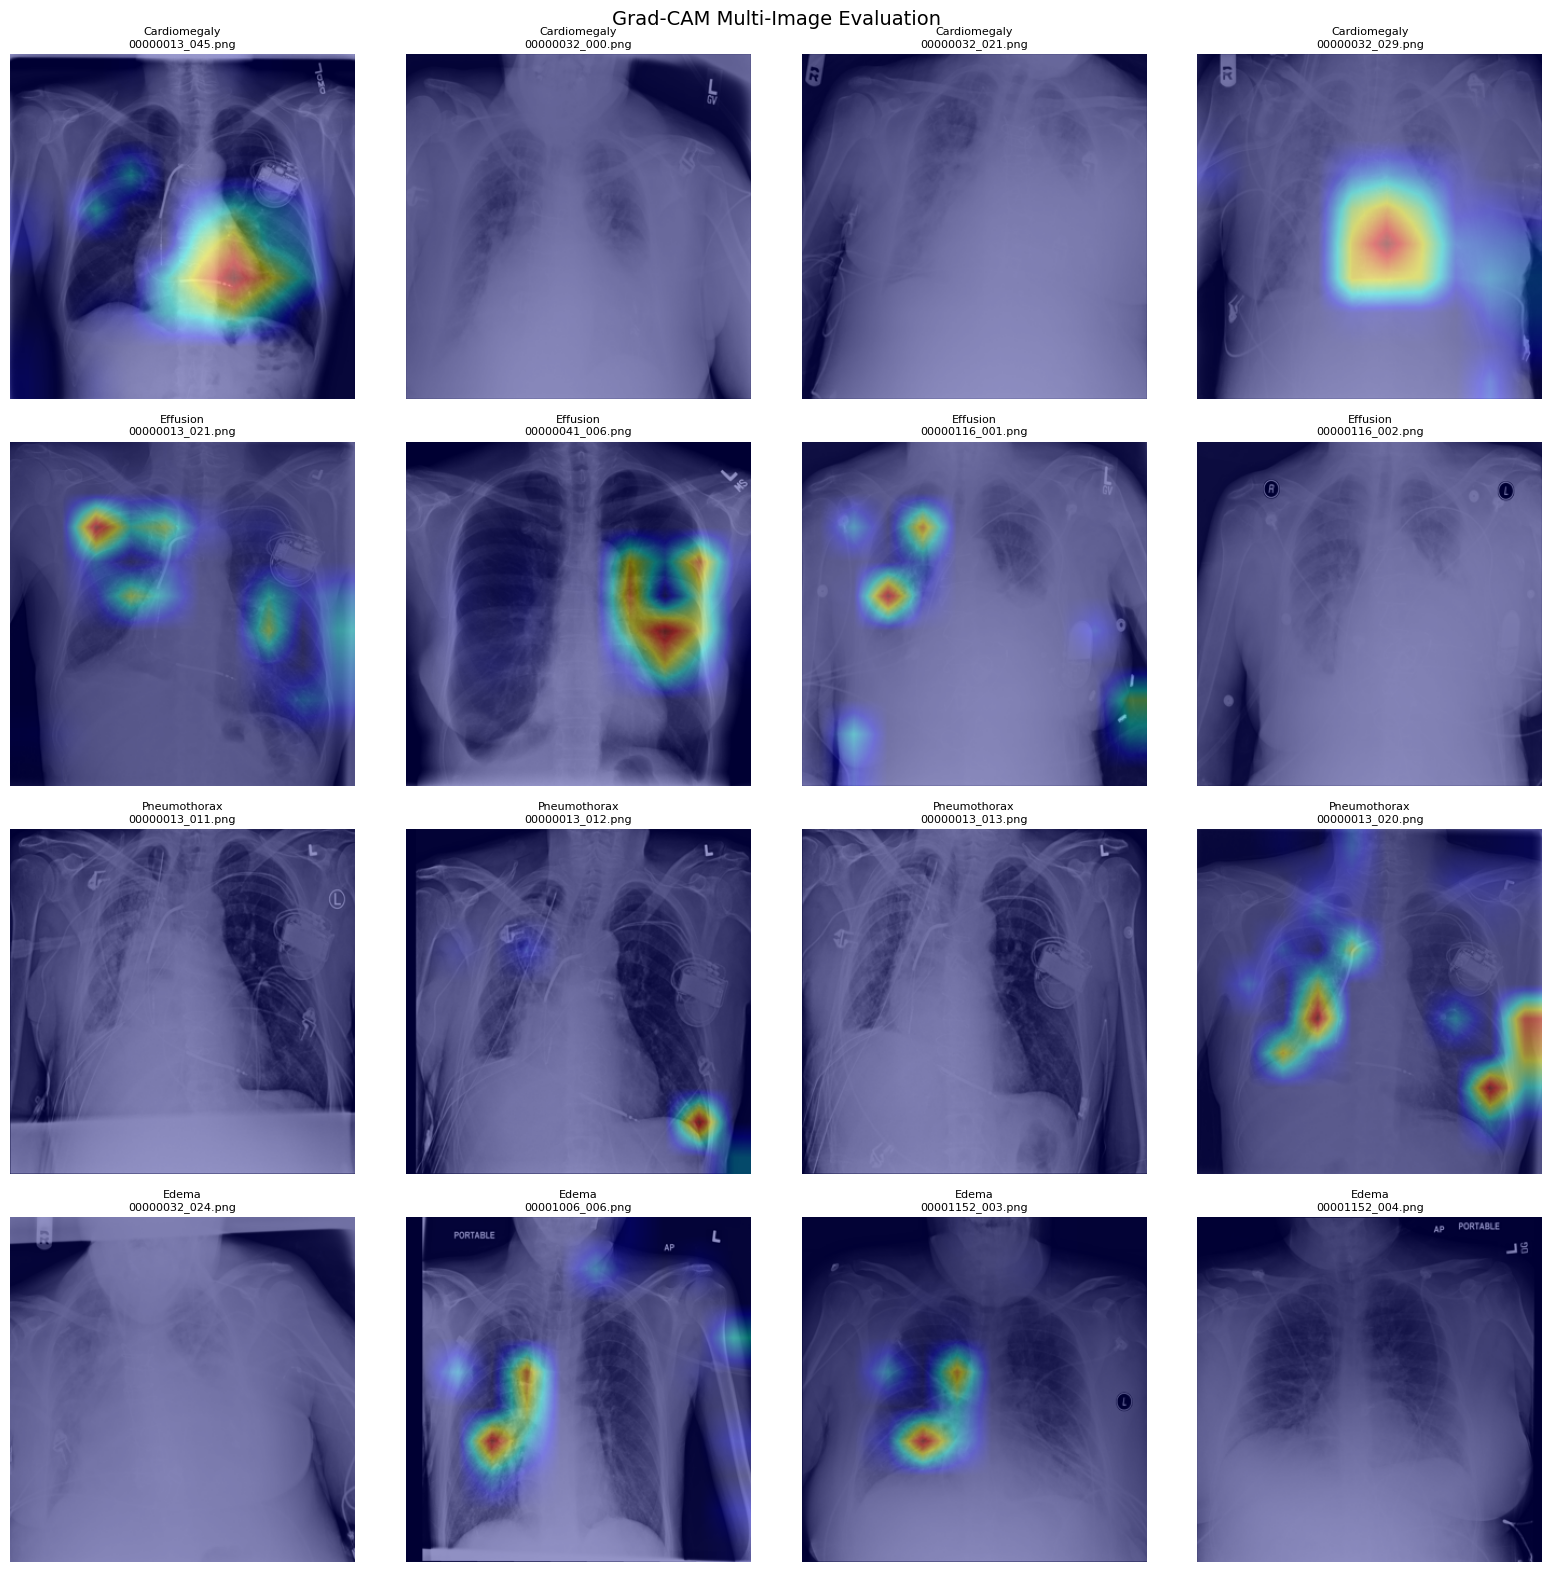

Done


In [28]:
# Test Grad-CAM on 5 images each for our strongest AUC classes
test_findings = {
    'Cardiomegaly': 'Cardiomegaly',  # should show heart center
    'Effusion': 'Effusion',           # should show lower lung/costophrenic angle
    'Pneumothorax': 'Pneumothorax',   # should show lung apex/pleural edge
    'Edema': 'Edema'                  # should show bilateral lung fields
}

fig, axes = plt.subplots(len(test_findings), 4, figsize=(16, 4*len(test_findings)))

for row_idx, (finding, label) in enumerate(test_findings.items()):
    # Get pure cases only
    pure_cases = test_df[test_df['Finding Labels'] == finding]
    if len(pure_cases) == 0:
        pure_cases = test_df[test_df['Finding Labels'].str.contains(finding)]
    
    class_idx = LABELS.index(label)
    
    for col_idx in range(4):
        if col_idx >= len(pure_cases):
            break
            
        sample = pure_cases.iloc[col_idx]
        
        # Find image
        image_path = None
        for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
            path = os.path.join(IMAGE_ROOT, folder, "images", sample['Image Index'])
            if os.path.exists(path):
                image_path = path
                break
        
        if image_path is None:
            continue
        
        # Generate heatmap
        img = PILImage.open(image_path).convert('RGB')
        original_np = np.array(img.resize((320, 320)))
        img_tensor = transform(img).unsqueeze(0)
        
        heatmap = gradcam.generate(img_tensor.clone(), class_idx)
        overlay, _ = gradcam.overlay(heatmap, original_np)
        
        axes[row_idx, col_idx].imshow(overlay)
        axes[row_idx, col_idx].set_title(f'{finding}\n{sample["Image Index"]}', fontsize=8)
        axes[row_idx, col_idx].axis('off')

plt.suptitle('Grad-CAM Multi-Image Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('D:/cxr-triage/notebooks/gradcam_multi_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done")

In [29]:
# Diagnose blank panels - check heatmap values and model confidence
# Test on known blank cases
blank_cases = [
    ('00000032_000.png', 'Cardiomegaly'),
    ('00000013_011.png', 'Pneumothorax'),
    ('00000032_024.png', 'Edema'),
]

for img_name, finding in blank_cases:
    print(f"\n{'='*50}")
    print(f"Image: {img_name} | Finding: {finding}")
    
    # Find image
    image_path = None
    for folder in [f"images_{str(i).zfill(3)}" for i in range(1, 13)]:
        path = os.path.join(IMAGE_ROOT, folder, "images", img_name)
        if os.path.exists(path):
            image_path = path
            break
    
    if image_path is None:
        print("IMAGE NOT FOUND")
        continue
    
    img = PILImage.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(DEVICE)
    
    # Get model confidence
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)
    
    class_idx = LABELS.index(finding)
    confidence = probs[0, class_idx].item()
    print(f"Model confidence for {finding}: {confidence:.4f}")
    
    # Generate heatmap and check values
    heatmap = gradcam.generate(img_tensor.cpu().clone(), class_idx)
    print(f"Heatmap min: {heatmap.min():.6f}")
    print(f"Heatmap max: {heatmap.max():.6f}")
    print(f"Heatmap mean: {heatmap.mean():.6f}")
    
    # Check if it's a rendering issue
    original_np = np.array(img.resize((320, 320)))
    overlay, heatmap_resized = gradcam.overlay(heatmap, original_np)
    print(f"Overlay min/max: {overlay.min()} / {overlay.max()}")
    print(f"Heatmap resized max: {heatmap_resized.max():.6f}")


Image: 00000032_000.png | Finding: Cardiomegaly
Model confidence for Cardiomegaly: 0.7142
Heatmap min: 0.000000
Heatmap max: 0.000000
Heatmap mean: 0.000000
Overlay min/max: 2 / 190
Heatmap resized max: 0.000000

Image: 00000013_011.png | Finding: Pneumothorax
Model confidence for Pneumothorax: 0.8374
Heatmap min: 0.000000
Heatmap max: 0.000000
Heatmap mean: 0.000000
Overlay min/max: 0 / 200
Heatmap resized max: 0.000000

Image: 00000032_024.png | Finding: Edema
Model confidence for Edema: 0.6393
Heatmap min: 0.000000
Heatmap max: 0.000000
Heatmap mean: 0.000000
Overlay min/max: 0 / 195
Heatmap resized max: 0.000000
